In [3]:
import pandas as pd
import os

def load_data(folder_path):
    """Loads raw CSV data from a folder and concatenates it into one DataFrame."""
    print("Loading data...")
    file_list = [file for file in os.listdir(folder_path) if file.endswith('.csv')]
    df_list = [pd.read_csv(os.path.join(folder_path, file)) for file in file_list]
    return pd.concat(df_list, ignore_index=True)

def clean_and_engineer(df):
    """Handles nulls, type conversions, and creates numeric features."""
    print("Cleaning data and engineering features...")
    df_clean = df.dropna().copy()
    
    # Time conversions
    df_clean['started_at'] = pd.to_datetime(df_clean['started_at'])
    df_clean['ended_at'] = pd.to_datetime(df_clean['ended_at'])
    
    # Feature Engineering (Numeric & Categorical)
    df_clean['ride_length_mins'] = (df_clean['ended_at'] - df_clean['started_at']).dt.total_seconds() / 60
    df_clean['day_of_week'] = df_clean['started_at'].dt.day_name()
    df_clean['hour'] = df_clean['started_at'].dt.hour
    
    # Filter out impossible negative/zero rides
    df_clean = df_clean[df_clean['ride_length_mins'] > 0]
    
    return df_clean

def extract_insights(df):
    """Proves the data is clean and extracts statistical variance."""
    print("\n--- 1. DATA VALIDATION: OVERALL ---")
    print(df['ride_length_mins'].describe())
    
    print("\n--- 2. BEHAVIORAL INSIGHT: AVERAGE RIDE LENGTH ---")
    print(df.groupby('member_casual')['ride_length_mins'].mean())
    
    print("\n--- 3. BEHAVIORAL INSIGHT: STATISTICAL VARIANCE ---")
    # Calculate the Standard Deviation (variance) of ride lengths
    casual_std = df[df['member_casual'] == 'casual']['ride_length_mins'].std()
    member_std = df[df['member_casual'] == 'member']['ride_length_mins'].std()
    
    print(f"Casual Standard Deviation: {casual_std:.1f} mins")
    print(f"Member Standard Deviation: {member_std:.1f} mins")
    print("\n💡 NOTE FOR REPORT: Notice how much higher the Casual variance is! This proves they are riding for unpredictable leisure, not strict commuting.")

# --- EXECUTE THE PIPELINE ---
# 1. Load the data (Make sure your folder is named 'raw_data')
raw_df = load_data('raw_data') 

# 2. Clean the data
cyclistic_clean = clean_and_engineer(raw_df)

# 3. Extract the stats
extract_insights(cyclistic_clean)

Loading data...
Cleaning data and engineering features...

--- 1. DATA VALIDATION: OVERALL ---
count    3.739226e+06
mean     1.595166e+01
std      3.475462e+01
min      1.300000e-03
25%      5.721733e+00
50%      9.869733e+00
75%      1.753570e+01
max      1.499638e+03
Name: ride_length_mins, dtype: float64

--- 2. BEHAVIORAL INSIGHT: AVERAGE RIDE LENGTH ---
member_casual
casual    22.283739
member    12.449820
Name: ride_length_mins, dtype: float64

--- 3. BEHAVIORAL INSIGHT: STATISTICAL VARIANCE ---
Casual Standard Deviation: 46.8 mins
Member Standard Deviation: 25.1 mins

💡 NOTE FOR REPORT: Notice how much higher the Casual variance is! This proves they are riding for unpredictable leisure, not strict commuting.


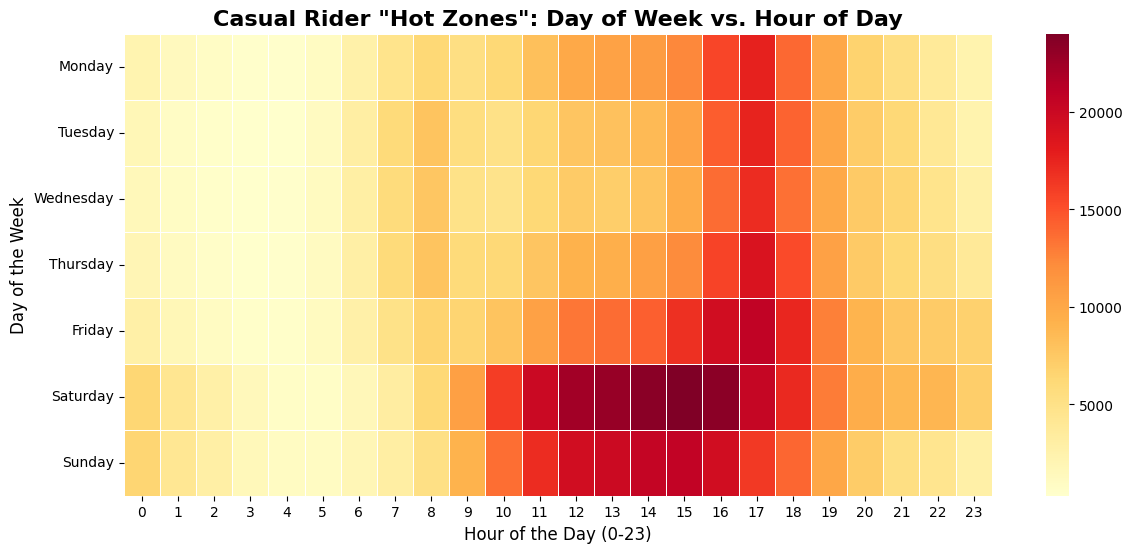

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter for ONLY Casual Riders (our target audience)
casual_riders = cyclistic_clean[cyclistic_clean['member_casual'] == 'casual']

# 2. Create a Pivot Table (Matrix) of Day vs. Hour
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = casual_riders.groupby(['day_of_week', 'hour'])['ride_id'].count().unstack()
heatmap_data = heatmap_data.reindex(days_order)

# 3. Plot the Heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=.5)

plt.title('Casual Rider "Hot Zones": Day of Week vs. Hour of Day', fontsize=16, fontweight='bold')
plt.xlabel('Hour of the Day (0-23)', fontsize=12)
plt.ylabel('Day of the Week', fontsize=12)
plt.show()

In [4]:
# The Advanced Insight: Bike Type Preference
bike_preference = cyclistic_clean.groupby(['member_casual', 'rideable_type'])['ride_id'].count()
print("\n--- ADVANCED INSIGHT: BIKE PREFERENCE ---")
print(bike_preference)


--- ADVANCED INSIGHT: BIKE PREFERENCE ---
member_casual  rideable_type
casual         classic_bike      663767
               electric_bike     667764
member         classic_bike     1271972
               electric_bike    1135723
Name: ride_id, dtype: int64
